In [1]:
import GWDALI as gw
import numpy as np
import matplotlib.pyplot as plt

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


Fail on loading jax.scypi.integrate.trapezoid
Fail on loading jax.scypi.integrate.trapezoid


### Setting Networks

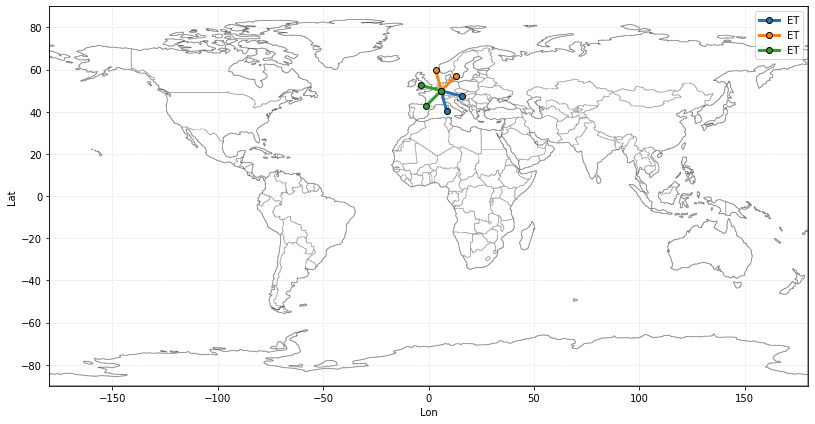

In [2]:
det_ET1 = {'name':'ET','lon':6, 'lat':50, 'rot':0, 'shape':60}
det_ET2 = {'name':'ET','lon':6, 'lat':50, 'rot':120, 'shape':60}
det_ET3 = {'name':'ET','lon':6, 'lat':50, 'rot':-120, 'shape':60}
detectors = [det_ET1, det_ET2, det_ET3]

fig = gw.draw_detectors(detectors)

### Setting GW Source Propertites

In [3]:
GwPrms = {}                                                                                                
GwPrms['dL'] 	= 10.96
GwPrms['Mc'] 	= 9.57
GwPrms['eta'] 	= 0.25
GwPrms['iota'] 	= 0.52
GwPrms['psi'] 	= 2.32
GwPrms['t_coal'] 	= 0.00
GwPrms['phi_coal'] 	= -1.37
GwPrms['RA'] 	= -135.75
GwPrms['Dec'] 	= 72.92
GwPrms['sz1'] 	= 0.31
GwPrms['sz2'] 	= 0.16

GwPrms['sx1'] 	= 0.00
GwPrms['sy1'] 	= 0.00

GwPrms['sx2'] 	= 0.00
GwPrms['sy2'] 	= 0.00

### Setting Parameters Range of the Grid for Posteriors Computations

In [4]:
npoints = 100
rad = np.pi/180

limits = {}
limits['dL']   = np.linspace(1,3*GwPrms['dL'],npoints)
limits['iota'] = np.linspace(0*rad,100*rad,npoints)

### Loading Precomputed DALI Tensors

In [5]:
tensors = np.load("DaliTensors.npz")

Fisher = tensors["Fisher"]
Db12   = tensors["Db12"]
Db22   = tensors["Db22"]
Tp13   = tensors["Tp13"]
Tp23   = tensors["Tp23"]
Tp33   = tensors["Tp33"]

Doublet = [Db12, Db22]
Triplet = [Tp13, Tp23, Tp33]

dali_tensors = [Fisher, Doublet, Triplet]

### Running GWDALI (Grid Method) With DALI Tensors Pre-Computed
- Check the last cells if you don't have already computed the tensors

In [6]:
res = gw.GWDALI(	GwPrms=GwPrms,
					detectors=detectors,
					FreeParams=["dL","iota"], # Free Parameters
					approx = "IMRPhenomD",
					method="Doublet",
					sampler="grid",
					new_priors = None,
					limits = limits, # Parameters limits on the Grid
					dali_tensors = dali_tensors,
					plot_signal=False,
					npoints=npoints, # Grid resolution (for 2D it is: npoints x npoints)
					remove_out=False, # Remove output path
					verbose = True,
					hide_info = False, # Hide GWDALI informatins
					output_name=f'gwdali_output/'
				)

#==============================
... Running GWDALI_v1 ...
#============================== 


 Free Parameters:  ['dL', 'iota']
 Method:  Doublet
 Approx:  IMRPhenomD 

>> Injections:
	 dL: 10.96
	 Mc: 9.57
	 eta: 0.25
	 iota: 0.52
	 psi: 2.32
	 t_coal: 0.00
	 phi_coal: -1.37
	 RA: -135.75
	 Dec: 72.92
	 sz1: 0.31
	 sz2: 0.16
	 sx1: 0.00
	 sy1: 0.00
	 sx2: 0.00
	 sy2: 0.00


ET (1) SNR = 12.361067233534916
ET (2) SNR = 12.070315084632922
ET (3) SNR = 10.972610855523756
Computing Tensors ...

<< DALI tensors loaded by the user >>

tensors loaded successfully!

>> DALI-Tensors OK!


### Reading Results

In [7]:
Results = res[0]

Prms, Posterior, likelihood_times = Results # It returns the parameters of the grid, the posteriors and an array of all likelihoods evaluation time

print(np.min(Posterior),np.max(Posterior))

xx, yy = np.meshgrid(Prms['dL'],Prms['iota'])

0.0 1.0


In [8]:
def PlotGrid(XX,YY,Post,gwprms,liketimes,title):
    PostN = Post/np.sum(Post)
    P = np.sort(np.ravel(PostN))
    Cum = np.array( [ np.sum(P[i:]) for i in range(len(P))] )
    levels = [ P[Cum<.9][0], P[Cum<.6][0]  ]

    fig = plt.figure(figsize=(10,5))
    plt.suptitle(title,weight='bold')
    plt.subplot(121)
    plt.contour(XX,YY,PostN,colors='k',levels=levels)
    plt.plot(gwprms['dL'],gwprms['iota'],'ro',mec='k',label='Injection')
    plt.xlabel('$d_L$ [Gpc]')
    plt.ylabel('$\\iota$ [rad]')
    plt.grid()
    plt.legend()

    plt.subplot(122)
    plt.hist(liketimes[1:]/1.e-3,bins=100,histtype='step',lw=2,color='k',density=True)
    plt.xlabel('likelihood call time [ms]')
    tm = np.mean(liketimes[1:]/1.e-3)
    plt.axvline(tm,color='r',label=f'$mean(t) \\rangle={tm:.2f} ms$')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    return fig

### Plotting Results (Doublet - Grid)

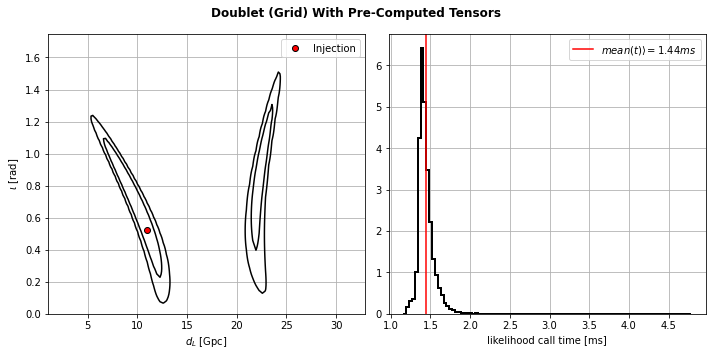

In [9]:
fig = PlotGrid(xx,yy,Posterior, GwPrms, likelihood_times, 'Doublet (Grid) With Pre-Computed Tensors')

### Running GWDALI (Doublet - Grid) Without Precomputed Tensors

In [10]:
res2 = gw.GWDALI(	GwPrms=GwPrms,
					detectors=detectors,
					FreeParams=["dL","iota"],
					approx = "IMRPhenomD",
					method="Doublet",
					sampler="grid",
					new_priors = None,
					limits = limits, # Parameters limits on the Grid
					diff_method = "numdiff", # or autodiff
                    step_size = [1.e-6,1.e-4], # relative step size for each order of derivative. It could be a single value (for all derivatives) or a list
					plot_signal=False,
					npoints=npoints, # Resolution of the grid for each parameter
					remove_out=False,
					verbose = True,
					hide_info = False,
					output_name=f'gwdali_output/'
				)

#==============================
... Running GWDALI_v1 ...
#============================== 


 Free Parameters:  ['dL', 'iota']
 Method:  Doublet
 Approx:  IMRPhenomD 

>> Injections:
	 dL: 10.96
	 Mc: 9.57
	 eta: 0.25
	 iota: 0.52
	 psi: 2.32
	 t_coal: 0.00
	 phi_coal: -1.37
	 RA: -135.75
	 Dec: 72.92
	 sz1: 0.31
	 sz2: 0.16
	 sx1: 0.00
	 sy1: 0.00
	 sx2: 0.00
	 sy2: 0.00


ET (1) SNR = 12.361067233534916
ET (2) SNR = 12.070315084632922
ET (3) SNR = 10.972610855523756
Computing Tensors ...
Loading JAX derivatives ...

*********************************** [1] Detector: ET ***********************************


==================================== Computing DALI Tensors (Doublet) ====================================



 # Computing First-Order Derivatives (diff_method = numdiff) .....

	 (dL)	 [1-2]	 Diff[dL] OK! 	(2 seconds)
	 (iota)	 [2-2]	 Diff[iota] OK! 	(1 seconds)

>> First Derivatives Concluded in 0min:4sec!



	Fisher(1|1) [1,1] ..............................

Computing Second-Orde

### Reading And Plotting Results

0.0 1.0


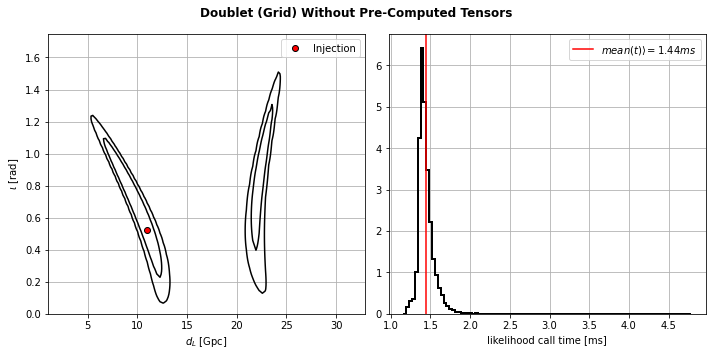

In [11]:
Results2 = res2[0]

Prms2, Posterior2, likelihood_times2 = Results2

print(np.min(Posterior2),np.max(Posterior2))

xx2, yy2 = np.meshgrid(Prms2['dL'],Prms2['iota'])

fig = PlotGrid(xx,yy,Posterior, GwPrms, likelihood_times, 'Doublet (Grid) Without Pre-Computed Tensors')